In [1]:
# 必要なパッケージ
if (!require("mclust")) install.packages("mclust")   # ARI
if (!require("aricode")) install.packages("aricode") # NMI

library(mclust)
library(aricode)

# --- CSVファイルの読み込み ---
file_3d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH_0.8.csv"  # MDS3軸のクラスタリング結果
file_100d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv"      # MDS100軸のクラスタリング結果

data_3d <- read.csv(file_3d, stringsAsFactors = FALSE)
data_100d <- read.csv(file_100d, stringsAsFactors = FALSE)

# --- 共通の変数名に絞る ---
common_vars <- intersect(data_3d$Variable, data_100d$Variable)

# --- クラスタ割り当てを抽出（順序を揃える）---
grpname_3d <- data_3d$Cluster[match(common_vars, data_3d$Variable)]
grpname_100d <- data_100d$Cluster[match(common_vars, data_100d$Variable)]

# --- クラスター結果を factor に変換 ---
grpname_3d <- as.factor(grpname_3d)
grpname_100d <- as.factor(grpname_100d)

# --- ARI / NMI 計算 ---
ari <- adjustedRandIndex(grpname_3d, grpname_100d)
nmi <- NMI(grpname_3d, grpname_100d)

# --- 結果表示 ---
cat("✅ Adjusted Rand Index (ARI):", round(ari, 4), "\n")
cat("✅ Normalized Mutual Information (NMI):", round(nmi, 4), "\n")


Loading required package: mclust

Package 'mclust' version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.

Loading required package: aricode



<U+2705> Adjusted Rand Index (ARI): 1 
<U+2705> Normalized Mutual Information (NMI): 1 


In [ ]:
# --- ファイルのパスを指定 ---
file_3d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH_0.8.csv"
file_100d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv"

# --- CSVファイルを読み込み ---
data_3d <- read.csv(file_3d, header = TRUE, row.names = 1)
data_100d <- read.csv(file_100d, header = TRUE, row.names = 1)

# --- クラスタ列の名前を確認して指定（例："grpname"） ---
# 必要に応じて names(data_3d) などで確認してください
grp_3d <- as.factor(data_3d$grpname)
grp_100d <- as.factor(data_100d$grpname)

# --- 変数名（行名を想定） ---
var_names <- rownames(data_3d)

# --- クラスタが異なるインデックスを抽出 ---
diff_index <- which(grp_3d != grp_100d)

# --- 差異のある変数一覧をデータフレームにまとめる ---
diff_df <- data.frame(
  Variable = var_names[diff_index],
  Cluster_3D = grp_3d[diff_index],
  Cluster_100D = grp_100d[diff_index]
)

# --- 表示 ---
print(diff_df)

# --- CSVとして保存（任意） ---
write.csv(diff_df, "cluster_diff_variables.csv", row.names = FALSE)


In [11]:
# --- ファイルのパスを指定 ---
file_3d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH_0.8.csv"   # MDS 3軸クラスタリング結果
file_100d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv"     # MDS 100軸クラスタリング結果

# --- CSVファイルを読み込み（変数名を行名として読み込む） ---
data_3d <- read.csv(file_3d, header = TRUE, row.names = 1)
data_100d <- read.csv(file_100d, header = TRUE, row.names = 1)

# --- クラスタ列名（※ご自身のデータに応じて変更してください） ---
cluster_colname <- "Cluster"

# --- クラスタ列の存在確認 ---
if (!cluster_colname %in% names(data_3d) || !cluster_colname %in% names(data_100d)) {
  stop(paste("クラスタ列 '", cluster_colname, "' が見つかりません。正しい列名を指定してください。"))
}

# --- 変数名（行名）とクラスタ情報を抽出 ---
var_names_3d <- rownames(data_3d)
clusters_3d <- data_3d[[cluster_colname]]

var_names_100d <- rownames(data_100d)
clusters_100d <- data_100d[[cluster_colname]]

# --- MDS 3軸クラスタ結果を表示 ---
cat("\n--- MDS 3D Clustering Result ---\n")
split_3d <- split(var_names_3d, clusters_3d)
for (k in sort(unique(clusters_3d))) {
  cat(sprintf("  - Cluster %s:\n", k))
  print(split_3d[[as.character(k)]])
  cat("\n")
}

# --- MDS 100軸クラスタ結果を表示 ---
cat("\n--- MDS 100D Clustering Result ---\n")
split_100d <- split(var_names_100d, clusters_100d)
for (k in sort(unique(clusters_100d))) {
  cat(sprintf("  - Cluster %s:\n", k))
  print(split_100d[[as.character(k)]])
  cat("\n")
}



--- MDS 3D Clustering Result ---
  - Cluster 1:
 [1] "Lay2thickness"           "LUMOp1M"                
 [3] "Lay2Mname_"              "Lay2Mname_PEDOTPSS"     
 [5] "Lay5electronodes1_Ca"    "Lay5electronodes1_MoOx" 
 [7] "SMILESsnamep1M_BTIBDTP2" "SMILESsnamep1M_PNTz4T"  
 [9] "Lay6electronodes2_Ag"    "Lay6electronodes2_Al"   
[11] "namesolvent1_oDCB"      

  - Cluster 2:
 [1] "Aonsetp1Mfilm"                   "MnkDap1M"                       
 [3] "HOMOp1M"                         "ALthickness"                    
 [5] "Egoptp1M"                        "RationM"                        
 [7] "Ratiop1M"                        "TApn"                           
 [9] "amountAditive"                   "Lay5electronodes1_LiF"          
[11] "SMILESsnameip1M_DTA"             "SMILESsnameip1M_EH.DBTA"        
[13] "SMILESsnamenM_PC61BM"            "SMILESsnamenM_PC71BM"           
[15] "SMILESsnamep1M_C6DPPBP"          "SMILESsnamep1M_DTA"             
[17] "SMILESsnamep1M_EHDBTA"       


--- MDS 100D Clustering Result ---
  - Cluster 1:
 [1] "Lay2thickness"           "LUMOp1M"                
 [3] "Lay2Mname_"              "Lay2Mname_PEDOTPSS"     
 [5] "Lay5electronodes1_Ca"    "Lay5electronodes1_MoOx" 
 [7] "SMILESsnamep1M_BTIBDTP2" "SMILESsnamep1M_PNTz4T"  
 [9] "Lay6electronodes2_Ag"    "Lay6electronodes2_Al"   
[11] "namesolvent1_oDCB"      

  - Cluster 2:
 [1] "Aonsetp1Mfilm"                   "MnkDap1M"                       
 [3] "HOMOp1M"                         "ALthickness"                    
 [5] "Egoptp1M"                        "RationM"                        
 [7] "Ratiop1M"                        "TApn"                           
 [9] "amountAditive"                   "Lay5electronodes1_LiF"          
[11] "SMILESsnameip1M_DTA"             "SMILESsnameip1M_EH.DBTA"        
[13] "SMILESsnamenM_PC61BM"            "SMILESsnamenM_PC71BM"           
[15] "SMILESsnamep1M_C6DPPBP"          "SMILESsnamep1M_DTA"             
[17] "SMILESsnamep1M_EHDBTA"     

Warning message in cor(mds_data):
"the standard deviation is zero"


   Cluster Mean_Correlation Mean_Correlation_Label
1        1          -0.1681                -0.1681
2        2           0.0086                 0.0086
3        3          -0.2929                -0.2929
4        4          -0.3415                -0.3415
5        5          -0.0011                -0.0011
6        6          -0.2815                -0.2815
7        7           0.0283                 0.0283
8        8          -0.2049                -0.2049
9        9          -0.3298                -0.3298
10      10          -0.2799                -0.2799
11      11          -0.3258                -0.3258
12      12           0.9945                 0.9945
13      13              NaN          NA or <2 vars


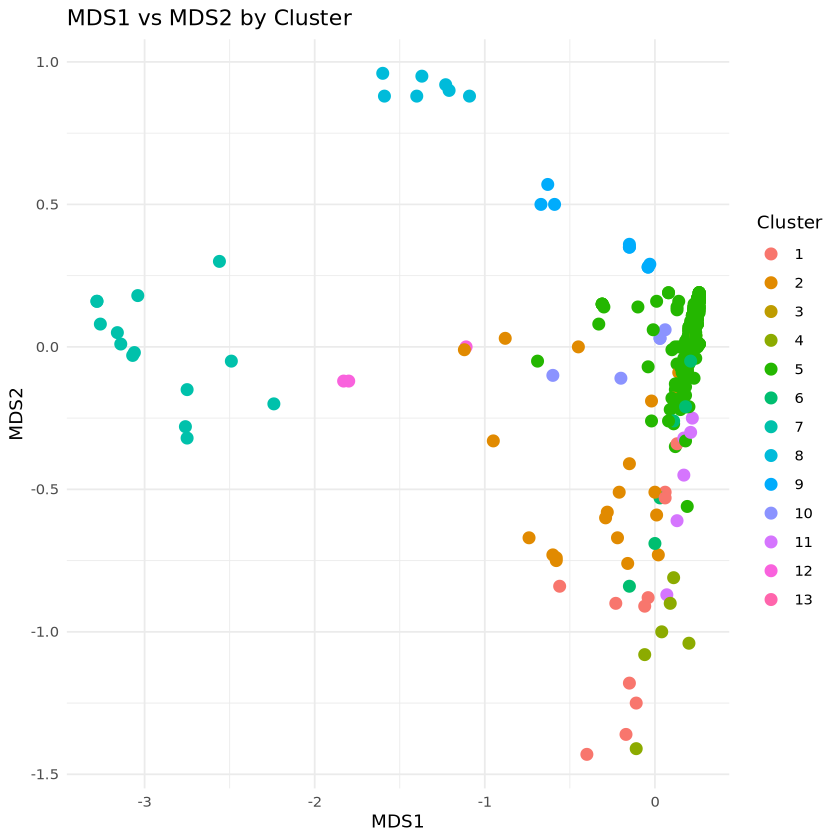

In [20]:
# --- 必要なパッケージ ---
library(ggplot2)

# --- データの読み込み（変数名を行名として使用） ---
df_r <- read.csv("New_NbClust_ptbiserial_GrpDist_All_0717_OH_0.8.csv", row.names = 1)

# --- クラスタのユニークなIDを取得 ---
cluster_ids <- unique(df_r$Cluster)

# --- クラスタごとの MDS1〜MDS3 の相関係数の平均を計算 ---
cor_means <- numeric(length(cluster_ids))

for (i in seq_along(cluster_ids)) {
  cl <- cluster_ids[i]
  # クラスタ内のMDS列だけ抽出
  mds_data <- df_r[df_r$Cluster == cl, c("MDS1", "MDS2", "MDS3")]
  # 相関行列の上三角要素の平均を計算
  cor_matrix <- cor(mds_data)
  upper_tri <- cor_matrix[upper.tri(cor_matrix)]
  cor_means[i] <- mean(upper_tri, na.rm = TRUE)
}

# --- 相関結果をデータフレーム化して表示 ---
cor_df <- data.frame(
  Cluster = cluster_ids,
  Mean_Correlation = round(cor_means, 4)
)

# NaN を "NA or <2 vars" に置き換えて見やすくする
cor_df$Mean_Correlation_Label <- ifelse(
  is.nan(cor_df$Mean_Correlation),
  "NA or <2 vars",
  sprintf("%.4f", cor_df$Mean_Correlation)
)

print(cor_df)


# --- MDS1 vs MDS2 のクラスタ可視化（散布図） ---
ggplot(df_r, aes(x = MDS1, y = MDS2, color = factor(Cluster))) +
  geom_point(size = 3) +
  labs(
    title = "MDS1 vs MDS2 by Cluster",
    x = "MDS1",
    y = "MDS2",
    color = "Cluster"
  ) +
  theme_minimal()


In [23]:
df <- read.csv("New_NbClust_ptbiserial_GrpDist_All_0717_OH_0.8.csv")
cluster_list <- split(df$Variable, df$Cluster)

# 表示
for (i in names(cluster_list)) {
  cat(paste0("▶ Cluster ", i, ":\n"))
  print(cluster_list[[i]])
  cat("\n")
}


<U+25B6> Cluster 1:
 [1] "Lay2thickness"           "LUMOp1M"                
 [3] "Lay2Mname_"              "Lay2Mname_PEDOTPSS"     
 [5] "Lay5electronodes1_Ca"    "Lay5electronodes1_MoOx" 
 [7] "SMILESsnamep1M_BTIBDTP2" "SMILESsnamep1M_PNTz4T"  
 [9] "Lay6electronodes2_Ag"    "Lay6electronodes2_Al"   
[11] "namesolvent1_oDCB"      

<U+25B6> Cluster 2:
 [1] "Aonsetp1Mfilm"                   "MnkDap1M"                       
 [3] "HOMOp1M"                         "ALthickness"                    
 [5] "Egoptp1M"                        "RationM"                        
 [7] "Ratiop1M"                        "TApn"                           
 [9] "amountAditive"                   "Lay5electronodes1_LiF"          
[11] "SMILESsnameip1M_DTA"             "SMILESsnameip1M_EH.DBTA"        
[13] "SMILESsnamenM_PC61BM"            "SMILESsnamenM_PC71BM"           
[15] "SMILESsnamep1M_C6DPPBP"          "SMILESsnamep1M_DTA"             
[17] "SMILESsnamep1M_EHDBTA"           "SMILESsnamep1M_PBDT

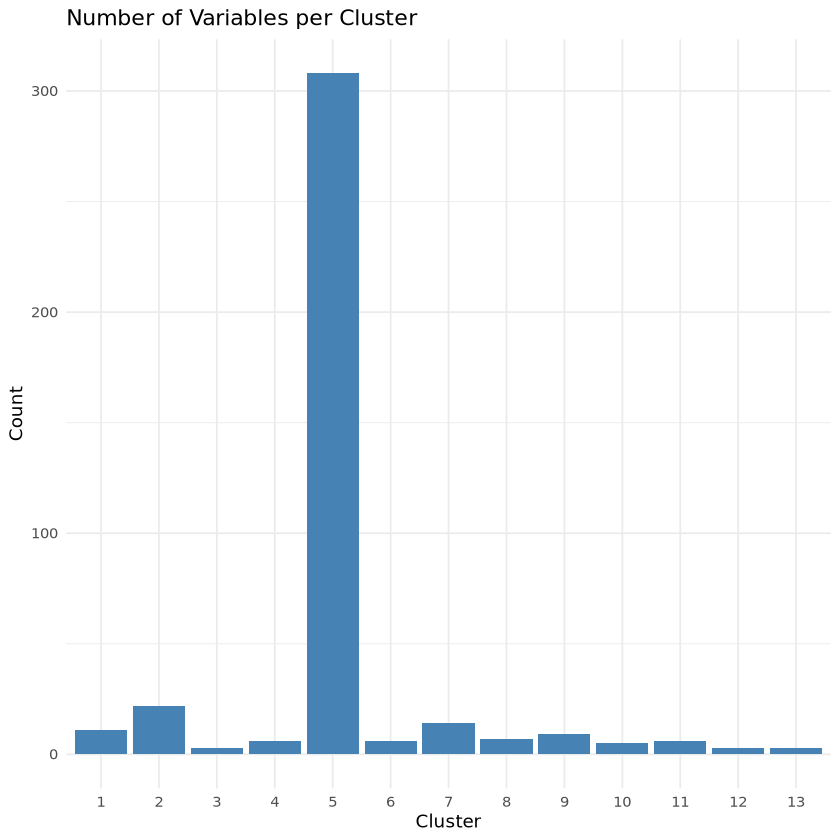

In [24]:
library(ggplot2)
ggplot(df, aes(x = as.factor(Cluster))) +
  geom_bar(fill = "steelblue") +
  labs(title = "Number of Variables per Cluster",
       x = "Cluster", y = "Count") +
  theme_minimal()


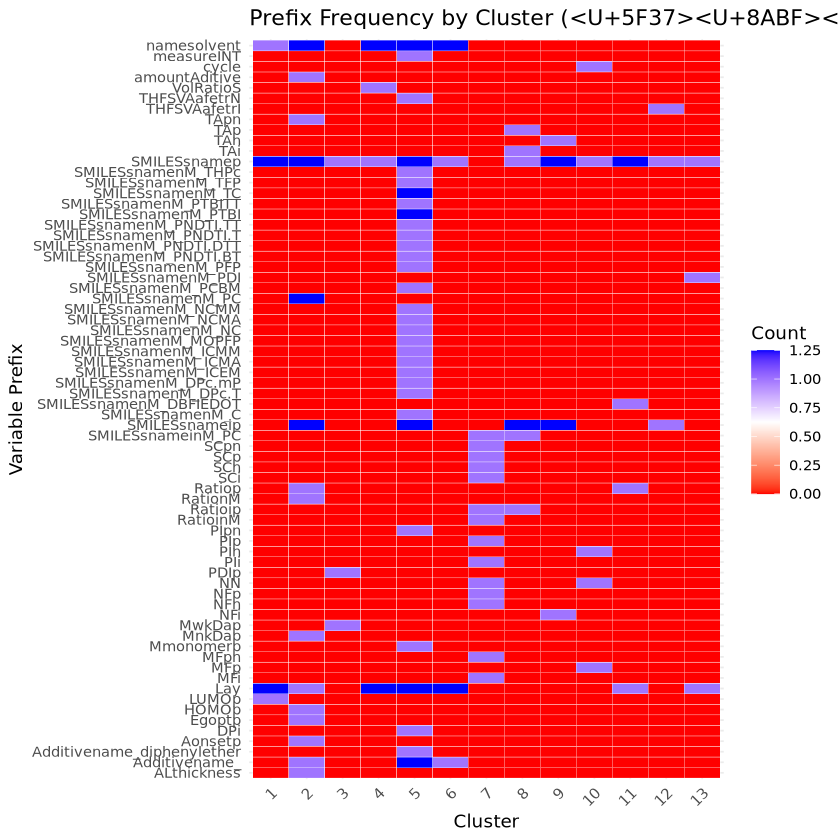

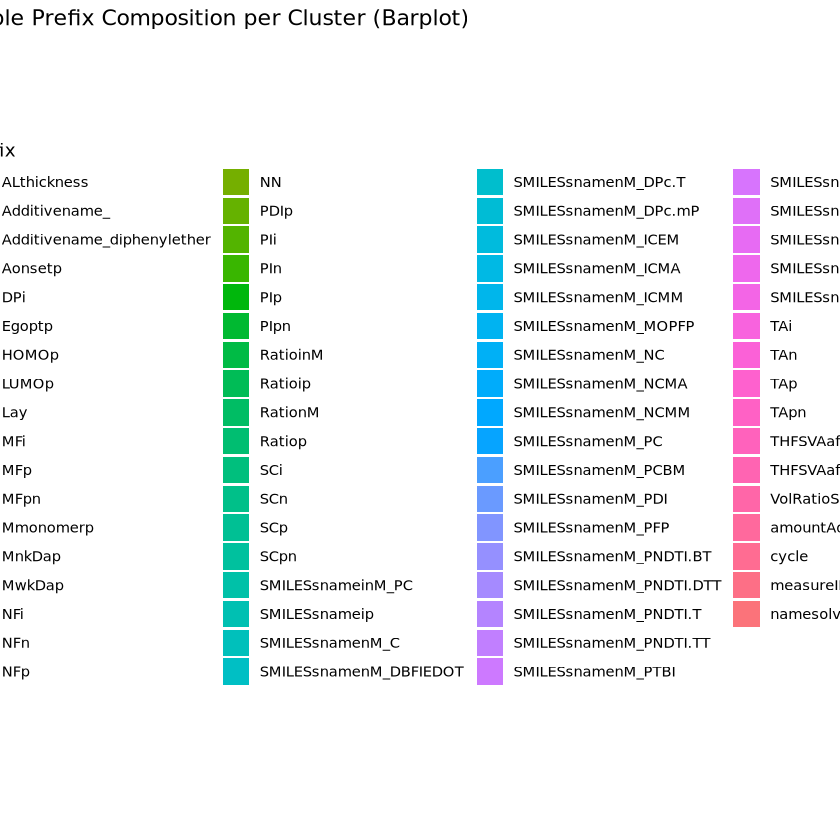

In [34]:
# --- 必要パッケージの読み込み（未インストールの場合は install.packages() してください） ---
library(ggplot2)
library(reshape2)

# --- データの読み込み ---
# 事前にデータファイルのパスを指定してください
file_path <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH_0.8.csv"
df <- read.csv(file_path)

# --- 変数名のプレフィックス抽出（例：SC1 → SC） ---
df$Prefix <- gsub("[0-9].*$", "", df$Variable)  # 数字以降を除去

# --- プレフィックス × クラスタ のクロス集計 ---
prefix_table <- table(df$Prefix, df$Cluster)
prefix_df <- as.data.frame(prefix_table)
colnames(prefix_df) <- c("Prefix", "Cluster", "Count")

# --- Cluster列を因子型に変換（x軸の順序の安定化のため） ---
prefix_df$Cluster <- as.factor(prefix_df$Cluster)

# --- 可視化①：ヒートマップ ---
# --- ヒートマップ（色スケールの上限を調整して強調） ---
library(ggplot2)

# --- カスタムヒートマップ描画 ---
ggplot(prefix_df, aes(x = Cluster, y = Prefix, fill = Count)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(
    low = "red",      # 下限色
    mid = "white",    # 中間色
    high = "blue",    # 上限色
    midpoint = (max(prefix_df$Count) * 0.005) / 2,  # 中間点を0.0005相当に
    limits = c(0, max(prefix_df$Count) * 0.005),    # 値の範囲を0〜最大の0.1%に制限
    oob = scales::squish   # 範囲外は端に寄せる（オーバーフロー抑制）
  ) +
  labs(title = "Prefix Frequency by Cluster (強調ヒートマップ)",
       x = "Cluster", y = "Variable Prefix", fill = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



# --- 可視化②：積み上げ棒グラフ ---
ggplot(prefix_df, aes(x = Cluster, y = Count, fill = Prefix)) +
  geom_bar(stat = "identity") +
  labs(title = "Variable Prefix Composition per Cluster (Barplot)",
       x = "Cluster", y = "Count") +
  theme_minimal() +
  theme(legend.position = "right")


In [13]:
# 相関行列（変数間）を用意（例：corData）
corData <- cor(numData, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0

# 各クラスタごとの相関係数平均を計算
cluster_means <- tapply(var_names, clusters, function(vars) {
  sub_cor <- corData[vars, vars]
  mean(sub_cor[lower.tri(sub_cor)])
})
print(cluster_means)


ERROR: Error: object 'numData' not found


In [14]:
# 変数形式情報を用意（例：Fingerprint or OH などの種類を保持）
format_info <- read.csv("variable_types.csv", row.names = 1)  # 形式列：Type

# クラスタごとの形式分布を集計
format_info$Cluster <- clusters[match(rownames(format_info), var_names)]
table(format_info$Cluster, format_info$Type)


Warning message in file(file, "rt"):
"cannot open file 'variable_types.csv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


In [15]:
library(caret)

# 目的変数と説明変数（X: データフレーム, Y: 目的変数ベクトル）
Y <- response_data$PCE  # 例
X <- explanatory_data   # 全体の説明変数データ

# クラスタごとにモデル構築（例：PLS）
results <- list()
for (cl in unique(clusters)) {
  vars <- var_names[clusters == cl]
  X_sub <- X[, vars]
  model <- train(X_sub, Y, method = "pls", trControl = trainControl(method = "cv"))
  results[[as.character(cl)]] <- model$results
}
print(results)


Loading required package: ggplot2

Loading required package: lattice



ERROR: Error: object 'response_data' not found


In [16]:
library(Rtsne)
tsne_out <- Rtsne(t(corData))  # 変数間の距離でt-SNE
df_tsne <- data.frame(tsne_out$Y)
df_tsne$Cluster <- as.factor(clusters)

ggplot(df_tsne, aes(x = X1, y = X2, color = Cluster)) +
  geom_point(size = 3) +
  theme_minimal() +
  labs(title = "t-SNE Visualization of Clusters")


ERROR: Error: object 'corData' not found


In [ ]:
# 必要なパッケージ
if (!require("mclust")) install.packages("mclust")   # ARI
if (!require("aricode")) install.packages("aricode") # NMI

library(mclust)
library(aricode)

# --- CSVファイルの読み込み ---
file_3d <- "NbClust_ptbiserial_Grp_delSTD0_0717_OH.csv"  # MDS3軸のクラスタリング結果
file_100d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv"      # MDS100軸のクラスタリング結果

data_3d <- read.csv(file_3d, stringsAsFactors = FALSE)
data_100d <- read.csv(file_100d, stringsAsFactors = FALSE)

# --- 共通の変数名に絞る ---
common_vars <- intersect(data_3d$Variable, data_100d$Variable)

# --- クラスタ割り当てを抽出（順序を揃える）---
grpname_3d <- data_3d$Cluster[match(common_vars, data_3d$Variable)]
grpname_100d <- data_100d$Cluster[match(common_vars, data_100d$Variable)]

# --- クラスター結果を factor に変換 ---
grpname_3d <- as.factor(grpname_3d)
grpname_100d <- as.factor(grpname_100d)

# --- ARI / NMI 計算 ---
ari <- adjustedRandIndex(grpname_3d, grpname_100d)
nmi <- NMI(grpname_3d, grpname_100d)

# --- 結果表示 ---
cat("✅ Adjusted Rand Index (ARI):", round(ari, 4), "\n")
cat("✅ Normalized Mutual Information (NMI):", round(nmi, 4), "\n")


Warning message in countPairs(c1, c2, i_order):
"subscript out of bounds (index 0 >= vector size 0)"
Warning message in countPairs(c1, c2, i_order):
"subscript out of bounds (index 830167504 >= vector size 0)"


In [ ]:
# --- CSVファイルの読み込み ---
file_3d <- "NbClust_ptbiserial_Grp_delSTD0_0717_OH.csv"  # MDS3軸のクラスタリング結果
file_100d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv"      # MDS100軸のクラスタリング結果

data_3d <- read.csv(file_3d, stringsAsFactors = FALSE)
data_100d <- read.csv(file_100d, stringsAsFactors = FALSE)
# --- 共通の変数名に絞る ---
common_vars <- intersect(data_3d$Variable, data_100d$Variable)

# --- マッチングインデックスの取得 ---
idx_3d <- match(common_vars, data_3d$Variable)
idx_100d <- match(common_vars, data_100d$Variable)

# --- NAを含む行を除去 ---
valid_idx <- which(!is.na(idx_3d) & !is.na(idx_100d))

grpname_3d <- as.factor(data_3d$Cluster[idx_3d[valid_idx]])
grpname_100d <- as.factor(data_100d$Cluster[idx_100d[valid_idx]])

# --- ARI / NMI 計算（関数を明示指定）---
ari <- mclust::adjustedRandIndex(grpname_3d, grpname_100d)
nmi <- aricode::NMI(grpname_3d, grpname_100d)

# --- 結果表示 ---
cat("✅ Adjusted Rand Index (ARI):", round(ari, 4), "\n")
cat("✅ Normalized Mutual Information (NMI):", round(nmi, 4), "\n")


Warning message in countPairs(c1, c2, i_order):
"subscript out of bounds (index 0 >= vector size 0)"
Warning message in countPairs(c1, c2, i_order):
"subscript out of bounds (index 1056877008 >= vector size 0)"


In [6]:
if (!require("mclust")) install.packages("mclust")


Loading required package: mclust

Package 'mclust' version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



In [1]:
length(common_vars)


ERROR: Error: object 'common_vars' not found


In [2]:
# --- パッケージ読み込み ---
if (!require("mclust")) install.packages("mclust")
if (!require("aricode")) install.packages("aricode")

library(mclust)
library(aricode)

# --- ファイル読み込み ---
file_3d <- "NbClust_ptbiserial_Grp_delSTD0_0717_OH.csv"
file_100d <- "New_NbClust_ptbiserial_GrpDist_All_0717_OH.csv"

data_3d <- read.csv(file_3d, stringsAsFactors = FALSE)
data_100d <- read.csv(file_100d, stringsAsFactors = FALSE)

# --- 変数名列の存在確認 ---
if (!("Variable" %in% colnames(data_3d)) || !("Variable" %in% colnames(data_100d))) {
  stop("❌ 'Variable' 列がどちらかのCSVに存在しません。")
}

# --- 不要な空白の除去 ---
data_3d$Variable <- trimws(data_3d$Variable)
data_100d$Variable <- trimws(data_100d$Variable)

# --- 共通の変数名を抽出 ---
common_vars <- intersect(data_3d$Variable, data_100d$Variable)

if (length(common_vars) == 0) {
  stop("❌ 共通の変数が見つかりませんでした。")
}

# --- インデックス取得とフィルタリング ---
idx_3d <- match(common_vars, data_3d$Variable)
idx_100d <- match(common_vars, data_100d$Variable)
valid_idx <- which(!is.na(idx_3d) & !is.na(idx_100d))

# --- クラスタ割り当て抽出（factor化） ---
grpname_3d <- as.factor(data_3d$Cluster[idx_3d[valid_idx]])
grpname_100d <- as.factor(data_100d$Cluster[idx_100d[valid_idx]])

# --- 長さチェック ---
if (length(grpname_3d) != length(grpname_100d)) {
  stop("❌ ラベルの長さが一致しません。")
}

# --- ARI / NMI 計算 ---
ari <- mclust::adjustedRandIndex(grpname_3d, grpname_100d)
nmi <- aricode::NMI(grpname_3d, grpname_100d)

# --- 結果表示 ---
cat("✅ Adjusted Rand Index (ARI):", round(ari, 4), "\n")
cat("✅ Normalized Mutual Information (NMI):", round(nmi, 4), "\n")


Loading required package: mclust

Package 'mclust' version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.

Loading required package: aricode



ERROR: Error: <U+274C> 'Variable' <U+5217><U+304C><U+3069><U+3061><U+3089><U+304B><U+306E>CSV<U+306B><U+5B58><U+5728><U+3057><U+307E><U+305B><U+3093><U+3002>


In [3]:
# 必要なパッケージ
if (!require("mclust")) install.packages("mclust")   # ARI
if (!require("aricode")) install.packages("aricode") # NMI

library(mclust)
library(aricode)

# --- CSVファイルの読み込み ---
file_3d <- "New_NbClust_ptbiserial_GrpDist_STD0_0725_OH_top3axes.csv"  # MDS3軸のクラスタリング結果
file_100d <- "New_NbClust_ptbiserial_GrpDist_STD0_0725_OH_top3axes.csv"      # MDS100軸のクラスタリング結果

data_3d <- read.csv(file_3d, stringsAsFactors = FALSE)
data_100d <- read.csv(file_100d, stringsAsFactors = FALSE)

# --- 共通の変数名に絞る ---
common_vars <- intersect(data_3d$Variable, data_100d$Variable)

# --- クラスタ割り当てを抽出（順序を揃える）---
grpname_3d <- data_3d$Cluster[match(common_vars, data_3d$Variable)]
grpname_100d <- data_100d$Cluster[match(common_vars, data_100d$Variable)]

# --- クラスター結果を factor に変換 ---
grpname_3d <- as.factor(grpname_3d)
grpname_100d <- as.factor(grpname_100d)

# --- ARI / NMI 計算 ---
ari <- adjustedRandIndex(grpname_3d, grpname_100d)
nmi <- NMI(grpname_3d, grpname_100d)

# --- 結果表示 ---
cat("✅ Adjusted Rand Index (ARI):", round(ari, 4), "\n")
cat("✅ Normalized Mutual Information (NMI):", round(nmi, 4), "\n")


<U+2705> Adjusted Rand Index (ARI): 0.2606 
<U+2705> Normalized Mutual Information (NMI): 0.1957 


In [ ]:
# 必要なパッケージ
if (!require("mclust")) install.packages("mclust")   # ARI
if (!require("aricode")) install.packages("aricode") # NMI

library(mclust)
library(aricode)

# --- CSVファイルの読み込み ---
file_3d <- "New_NbClust_ptbiserial_GrpDist_STD0_0725_OH_top3axes.csv"  # MDS3軸のクラスタリング結果
file_100d <- "New_NbClust_ptbiserial_GrpDist_STD0_0725_OH_top3axes.csv"      # MDS100軸のクラスタリング結果

data_3d <- read.csv(file_3d, stringsAsFactors = FALSE)
data_100d <- read.csv(file_100d, stringsAsFactors = FALSE)

# --- 共通の変数名に絞る ---
common_vars <- intersect(data_3d$Variable, data_100d$Variable)

# --- クラスタ割り当てを抽出（順序を揃える）---
grpname_3d <- data_3d$Cluster[match(common_vars, data_3d$Variable)]
grpname_100d <- data_100d$Cluster[match(common_vars, data_100d$Variable)]

# --- クラスター結果を factor に変換 ---
grpname_3d <- as.factor(grpname_3d)
grpname_100d <- as.factor(grpname_100d)

# --- ARI / NMI 計算 ---
ari <- adjustedRandIndex(grpname_3d, grpname_100d)
nmi <- NMI(grpname_3d, grpname_100d)

# --- 結果表示 ---
cat("✅ Adjusted Rand Index (ARI):", round(ari, 4), "\n")
cat("✅ Normalized Mutual Information (NMI):", round(nmi, 4), "\n")


In [5]:
# --- パッケージの読み込み ---
if (!require("mclust")) install.packages("mclust")
if (!require("aricode")) install.packages("aricode")
library(mclust)
library(aricode)

# --- 使用するクラスタリング指標 ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# --- 各クラスタリング結果を読み込んで保存 ---
cluster_data <- list()

for (index_name in index_list) {
  filename <- paste0("New_NbClust_", index_name, "_GrpDist_STD0_0725_OH_top3axes.csv")
  df <- read.csv(filename, stringsAsFactors = FALSE)
  cluster_data[[index_name]] <- df
}

# --- ARI / NMI 行列の初期化 ---
n <- length(index_list)
ari_matrix <- matrix(NA, n, n, dimnames = list(index_list, index_list))
nmi_matrix <- matrix(NA, n, n, dimnames = list(index_list, index_list))

# --- 各ペアで計算 ---
for (i in 1:n) {
  for (j in 1:n) {
    data_i <- cluster_data[[index_list[i]]]
    data_j <- cluster_data[[index_list[j]]]

    common_vars <- intersect(data_i$Variable, data_j$Variable)
    grp_i <- as.factor(data_i$Cluster[match(common_vars, data_i$Variable)])
    grp_j <- as.factor(data_j$Cluster[match(common_vars, data_j$Variable)])

    ari_matrix[i, j] <- adjustedRandIndex(grp_i, grp_j)
    nmi_matrix[i, j] <- NMI(grp_i, grp_j)
  }
}

# --- データフレーム化と四捨五入 ---
ari_df <- as.data.frame(round(ari_matrix, 4))
nmi_df <- as.data.frame(round(nmi_matrix, 4))

# --- 結果の表示（コンソール）---
cat("\n✅ Adjusted Rand Index (ARI) Matrix:\n")
print(ari_df)

cat("\n✅ Normalized Mutual Information (NMI) Matrix:\n")
print(nmi_df)

# --- ファイル保存 ---
write.csv(ari_df, "ARI_matrix_top3axes.csv", row.names = TRUE)
write.csv(nmi_df, "NMI_matrix_top3axes.csv", row.names = TRUE)

cat("\n✅ ARI / NMI 行列をCSVにも出力しました。\n")



<U+2705> Adjusted Rand Index (ARI) Matrix:
           silhouette   dunn    gap     ch     db ptbiserial
silhouette     1.0000 1.0000 0.9916 0.0102 1.0000     1.0000
dunn           1.0000 1.0000 0.9916 0.0102 1.0000     1.0000
gap            0.9916 0.9916 1.0000 0.0100 0.9916     0.9916
ch             0.0102 0.0102 0.0100 1.0000 0.0102     0.0102
db             1.0000 1.0000 0.9916 0.0102 1.0000     1.0000
ptbiserial     1.0000 1.0000 0.9916 0.0102 1.0000     1.0000

<U+2705> Normalized Mutual Information (NMI) Matrix:
           silhouette   dunn    gap     ch     db ptbiserial
silhouette     1.0000 1.0000 0.8522 0.0708 1.0000     1.0000
dunn           1.0000 1.0000 0.8522 0.0708 1.0000     1.0000
gap            0.8522 0.8522 1.0000 0.0603 0.8522     0.8522
ch             0.0708 0.0708 0.0603 1.0000 0.0708     0.0708
db             1.0000 1.0000 0.8522 0.0708 1.0000     1.0000
ptbiserial     1.0000 1.0000 0.8522 0.0708 1.0000     1.0000

<U+2705> ARI / NMI <U+884C><U+5217><U+3092>CSV<

In [9]:
# --- 必要パッケージ ---
if (!require("mclust")) install.packages("mclust")
if (!require("aricode")) install.packages("aricode")
library(mclust)
library(aricode)

# --- クラスタリング指標とファイル名対応 ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")
file_versions <- c("0.8", "top3")
file_labels <- as.vector(t(outer(index_list, file_versions, paste, sep = "_")))

# --- ファイルパス辞書の作成 ---
file_paths <- setNames(
  nm = file_labels,
  object = sapply(file_labels, function(lbl) {
    parts <- strsplit(lbl, "_")[[1]]
    method <- parts[1]
    ver <- parts[2]
    if (ver == "0.8") {
      paste0("New_NbClust_", method, "_GrpDist_STD0_07_OH_0.8.csv")
    } else {
      paste0("New_NbClust_", method, "_GrpDist_STD0_0725_OH_top3axes.csv")
    }
  }, USE.NAMES = FALSE)
)

# --- クラスタ割り当て読み込み関数 ---
read_clusters <- function(filepath) {
  df <- read.csv(filepath, stringsAsFactors = FALSE)
  return(setNames(as.factor(df$Cluster), df$Variable))
}

# --- 全クラスタ割り当てとクラスタ数を取得 ---
cluster_data <- lapply(file_paths, read_clusters)
cluster_counts <- sapply(cluster_data, function(x) length(unique(x)))

# --- 初期化 ---
n <- length(file_labels)
ari_matrix <- matrix("", nrow = n, ncol = n, dimnames = list(file_labels, file_labels))
nmi_matrix <- matrix("", nrow = n, ncol = n, dimnames = list(file_labels, file_labels))

# --- 比較ループ ---
for (i in 1:n) {
  for (j in 1:n) {
    x <- cluster_data[[i]]
    y <- cluster_data[[j]]
    common <- intersect(names(x), names(y))
    if (length(common) > 0) {
      ari_val <- round(adjustedRandIndex(x[common], y[common]), 4)
      nmi_val <- round(NMI(x[common], y[common]), 4)
      ari_matrix[i, j] <- sprintf("%.4f (%d/%d)", ari_val, cluster_counts[j], cluster_counts[i])
      nmi_matrix[i, j] <- sprintf("%.4f (%d/%d)", nmi_val, cluster_counts[j], cluster_counts[i])
    }
  }
}

# --- 出力 ---
ari_df <- as.data.frame(ari_matrix)
nmi_df <- as.data.frame(nmi_matrix)

write.csv(ari_df, "ARI_matrix_compare_all_with_clusters.csv", row.names = TRUE)
write.csv(nmi_df, "NMI_matrix_compare_all_with_clusters.csv", row.names = TRUE)

cat("✅ Adjusted Rand Index (ARI) with Cluster Counts:\n")
print(ari_df, right = FALSE)

cat("\n✅ Normalized Mutual Information (NMI) with Cluster Counts:\n")
print(nmi_df, right = FALSE)

cat("\n📄 ファイル出力済: ARI_matrix_compare_all_with_clusters.csv / NMI_matrix_compare_all_with_clusters.csv\n")


<U+2705> Adjusted Rand Index (ARI) with Cluster Counts:
                silhouette_0.8 silhouette_top3 dunn_0.8       dunn_top3     
silhouette_0.8  1.0000 (2/2)   0.9916 (3/2)    0.9916 (3/2)   0.9916 (3/2)  
silhouette_top3 0.9916 (2/3)   1.0000 (3/3)    1.0000 (3/3)   1.0000 (3/3)  
dunn_0.8        0.9916 (2/3)   1.0000 (3/3)    1.0000 (3/3)   1.0000 (3/3)  
dunn_top3       0.9916 (2/3)   1.0000 (3/3)    1.0000 (3/3)   1.0000 (3/3)  
gap_0.8         1.0000 (2/2)   0.9916 (3/2)    0.9916 (3/2)   0.9916 (3/2)  
gap_top3        1.0000 (2/2)   0.9916 (3/2)    0.9916 (3/2)   0.9916 (3/2)  
ch_0.8          1.0000 (2/2)   0.9916 (3/2)    0.9916 (3/2)   0.9916 (3/2)  
ch_top3         0.0100 (2/100) 0.0102 (3/100)  0.0102 (3/100) 0.0102 (3/100)
db_0.8          0.9916 (2/3)   1.0000 (3/3)    1.0000 (3/3)   1.0000 (3/3)  
db_top3         0.9916 (2/3)   1.0000 (3/3)    1.0000 (3/3)   1.0000 (3/3)  
ptbiserial_0.8  0.2568 (2/22)  0.2606 (3/22)   0.2606 (3/22)  0.2606 (3/22) 
ptbiserial_top3 0.99